Database Connection & Setup

In [5]:
%pip install pandas matplotlib seaborn sqlalchemy pymysql

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

DB_USER = "root"
DB_PASS = "Prateek%4095"
DB_HOST = "localhost"
DB_PORT = "3306"
DB_NAME = "olist_db"

connection_string = f"mysql+pymysql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
engine = create_engine(connection_string)

query = """
SELECT 
    DATE_FORMAT(o.order_purchase_timestamp, '%%Y-%%m') AS sales_month,
    COUNT(DISTINCT o.order_id) AS total_orders,
    ROUND(SUM(p.payment_value), 2) AS total_revenue
FROM orders o
JOIN order_payments p ON o.order_id = p.order_id
WHERE o.order_purchase_timestamp IS NOT NULL
GROUP BY sales_month
ORDER BY sales_month ASC;
"""

with engine.connect() as connection:
    df_monthly = pd.read_sql(query, con=connection)
df_monthly.head()

,sales_month,total_orders,total_revenue
0,2016-09,3,252.24
1,2016-10,324,59090.48
2,2016-12,1,19.62
3,2017-01,800,138488.04
4,2017-02,1780,291908.01


Monthly Revenue & Growth Trends

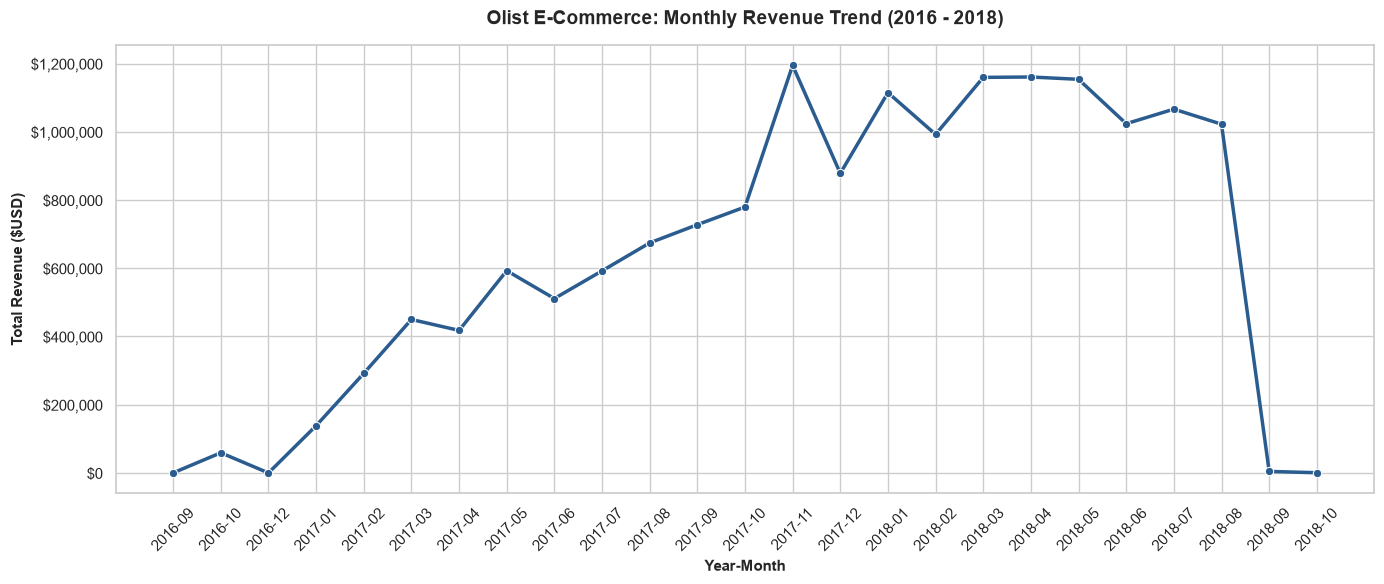

In [10]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6))

ax = sns.lineplot(
    data=df_monthly, 
    x='sales_month', 
    y='total_revenue', 
    marker='o', 
    color='#2b5c8f', 
    linewidth=2.5
)

plt.title('Olist E-Commerce: Monthly Revenue Trend (2016 - 2018)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Year-Month', fontsize=11, fontweight='bold')
plt.ylabel('Total Revenue ($USD)', fontsize=11, fontweight='bold')
plt.xticks(rotation=45)

import matplotlib.ticker as ticker
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))

plt.tight_layout()
plt.show()

Regional Revenue Performance

C:\Users\baser\AppData\Local\Temp\ipykernel_16184\1941844284.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


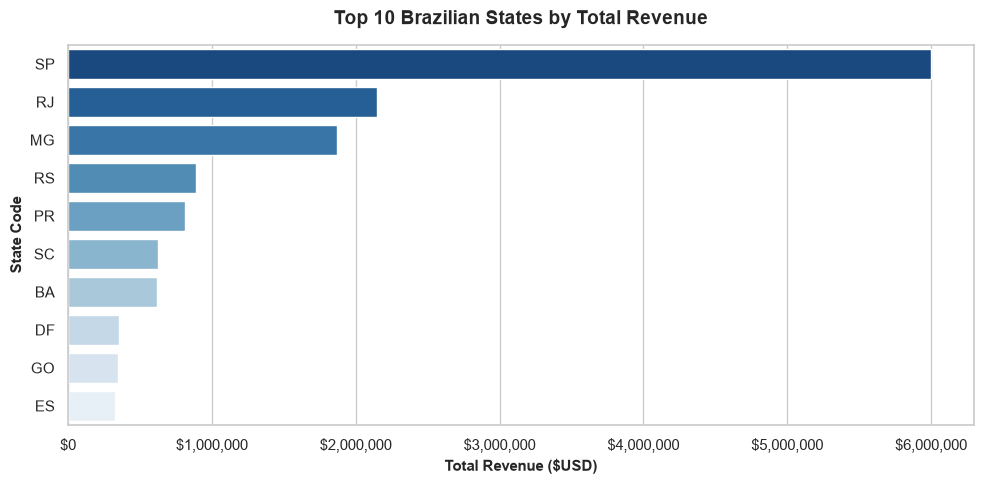

In [11]:
query_regional = """
SELECT 
    c.customer_state,
    COUNT(DISTINCT o.order_id) AS total_orders,
    ROUND(SUM(p.payment_value), 2) AS total_revenue
FROM orders o
JOIN order_payments p ON o.order_id = p.order_id
JOIN customers c ON o.customer_id = c.customer_id
GROUP BY c.customer_state
ORDER BY total_revenue DESC
LIMIT 10;
"""

with engine.connect() as connection:
    df_regional = pd.read_sql(query_regional, con=connection)

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=df_regional,
    x='total_revenue',
    y='customer_state',
    palette='Blues_r'
)

plt.title('Top 10 Brazilian States by Total Revenue', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Total Revenue ($USD)', fontsize=11, fontweight='bold')
plt.ylabel('State Code', fontsize=11, fontweight='bold')
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))

plt.tight_layout()
plt.show()

Payment Method & Installment Breakdown

C:\Users\baser\AppData\Local\Temp\ipykernel_16184\1331798157.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


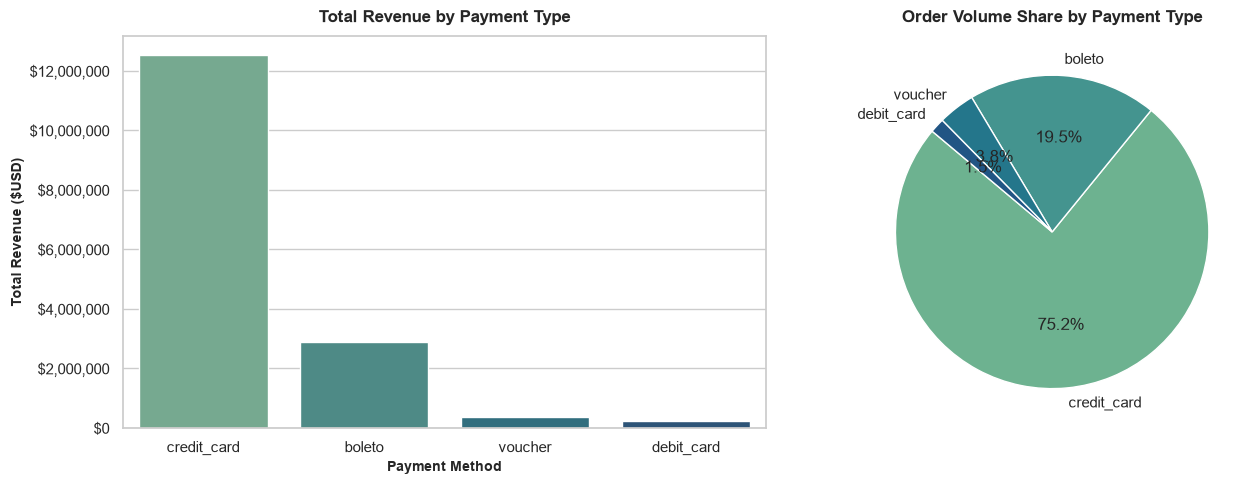

In [12]:
query_payments = """
SELECT 
    p.payment_type,
    COUNT(DISTINCT p.order_id) AS total_orders,
    ROUND(SUM(p.payment_value), 2) AS total_revenue,
    ROUND(AVG(p.payment_installments), 1) AS avg_installments
FROM order_payments p
WHERE p.payment_type != 'not_defined'
GROUP BY p.payment_type
ORDER BY total_revenue DESC;
"""

with engine.connect() as connection:
    df_payments = pd.read_sql(query_payments, con=connection)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=df_payments, 
    x='payment_type', 
    y='total_revenue', 
    ax=ax1, 
    palette='crest'
)
ax1.set_title('Total Revenue by Payment Type', fontsize=12, fontweight='bold', pad=10)
ax1.set_xlabel('Payment Method', fontsize=10, fontweight='bold')
ax1.set_ylabel('Total Revenue ($USD)', fontsize=10, fontweight='bold')
ax1.yaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))

ax2.pie(
    df_payments['total_orders'], 
    labels=df_payments['payment_type'], 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=sns.color_palette('crest', len(df_payments))
)
ax2.set_title('Order Volume Share by Payment Type', fontsize=12, fontweight='bold', pad=10)

plt.tight_layout()
plt.show()